In [2]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("bank.csv")

# View first 5 rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
# Check column names
print(df.columns)

# Clean column names (remove spaces)
df.columns = df.columns.str.strip()

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


In [4]:
# X = features, y = target
X = df.drop("deposit", axis=1)
y = df["deposit"]

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

# Also encode target
y = le.fit_transform(y)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Create model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
# Predict on test set
y_pred = model.predict(X_test)

Confusion Matrix:
[[952 214]
 [158 909]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1166
           1       0.81      0.85      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



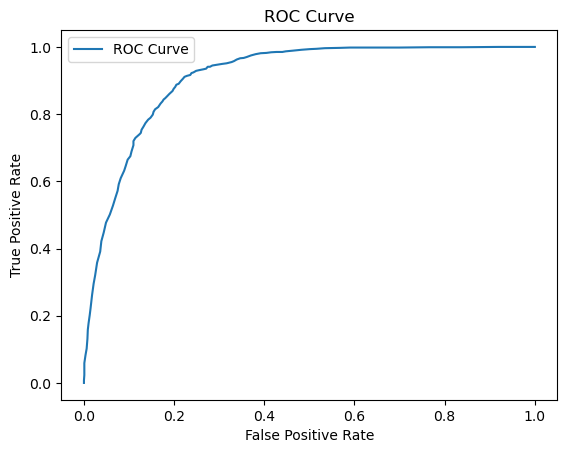

In [9]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
import shap

# Create TreeExplainer (works best for RandomForest)
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Summary Plot (shows feature importance)
shap.summary_plot(shap_values[1], X_test)

# Waterfall plot for first prediction
shap.plots._waterfall.waterfall_legacy(explainer.expected_value[1], shap_values[1][0], X_test.iloc[0])

## Problem Statement
The objective of this project is to predict whether a bank customer will subscribe to a term deposit based on marketing campaign data.

## Dataset Description
The dataset contains customer information such as age, job, marital status, balance, and previous marketing interactions. 
The target variable is 'deposit', which indicates whether the customer subscribed (yes/no).

## Model Used
A Random Forest Classifier was used for prediction. 
It is an ensemble learning method that builds multiple decision trees and improves prediction accuracy.

## Results
The model achieved an accuracy of approximately 85%. 
The confusion matrix shows that the model performs well in predicting both classes with minimal errors.

## SHAP Explanation
SHAP (SHapley Additive exPlanations) was used to interpret the model. 
It shows how each feature contributes to the prediction. 
This helps in understanding customer behavior and model decisions.

## Conclusion
The model successfully predicts customer subscription behavior. 
This can help banks target potential customers more effectively and improve marketing strategies.